In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_parquet("../../data/processed/pickup_clean.parquet")

print(f"Loaded: {df.shape}")
print(f"Disruption rate: {df['is_disrupted'].mean()*100:.2f}%")
print(f"Columns: {list(df.columns)}")

Loaded: (6064908, 18)
Disruption rate: 1.82%
Columns: ['order_id', 'city', 'courier_id', 'accept_time', 'time_window_start', 'time_window_end', 'lng', 'lat', 'aoi_id', 'aoi_type', 'pickup_time', 'pickup_gps_lng', 'pickup_gps_lat', 'accept_gps_lng', 'accept_gps_lat', 'ds', 'delay_minutes', 'is_disrupted']


In [ ]:
df['hour_of_day'] = df['accept_time'].dt.hour

hourly = df.groupby('hour_of_day').agg(
    disruption_rate=('is_disrupted', 'mean'),
    order_count=('is_disrupted', 'size')
).reset_index()
hourly['disruption_rate'] *= 100

print(hourly.to_string(index=False))

 hour_of_day  disruption_rate  order_count
           0         1.515152          132
           2         0.000000            1
           5        33.333333            3
           6         1.703320        18552
           7         2.354934      1474139
           8         1.912422      1573607
           9         1.859032       793370
          10         1.795561       416026
          11         1.606699       300803
          12         1.718618       308271
          13         1.258171       304569
          14         1.264773       300291
          15         0.813868       274123
          16         0.861479       284859
          17         2.192910        12130
          18         4.217185         1897
          19         7.310705          766
          20         6.185567          485
          21         7.981221          426
          22         5.050505          297
          23         1.242236          161


In [ ]:
all_hours = set(range(24))
present_hours = set(df['hour_of_day'].unique())
missing_hours = sorted(all_hours - present_hours)
print(f"Hours with zero orders: {missing_hours}")

hour_counts = df['hour_of_day'].value_counts().sort_index()
print("\nOrders per hour (all hours present in data):")
print(hour_counts.to_string())

Hours with zero orders: [1, 3, 4]

Orders per hour (all hours present in data):
hour_of_day
0         132
2           1
5           3
6       18552
7     1474139
8     1573607
9      793370
10     416026
11     300803
12     308271
13     304569
14     300291
15     274123
16     284859
17      12130
18       1897
19        766
20        485
21        426
22        297
23        161


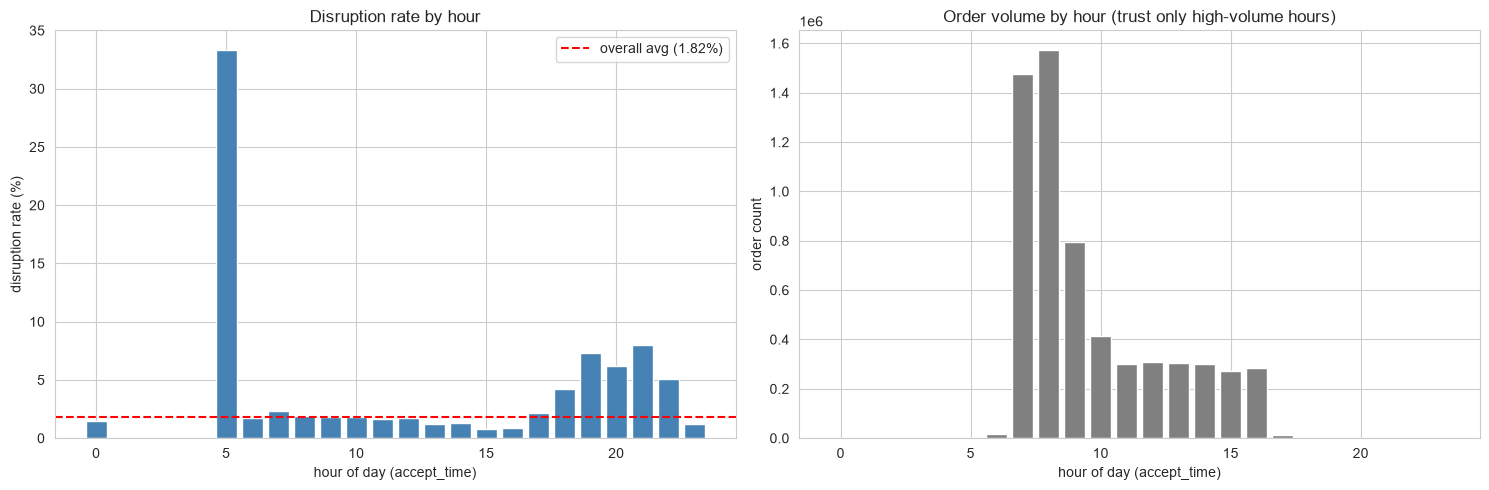

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.bar(hourly['hour_of_day'], hourly['disruption_rate'], color='steelblue')
ax1.axhline(1.82, color='red', linestyle='--', label='overall avg (1.82%)')
ax1.set_xlabel('hour of day (accept_time)')
ax1.set_ylabel('disruption rate (%)')
ax1.set_title('Disruption rate by hour')
ax1.legend()

ax2.bar(hourly['hour_of_day'], hourly['order_count'], color='gray')
ax2.set_xlabel('hour of day (accept_time)')
ax2.set_ylabel('order count')

ax2.set_title('Order volume by hour (trust only high-volume hours)')

plt.tight_layout()
plt.show()

In [5]:
city_stats = df.groupby('city').agg(
    disruption_rate=('is_disrupted', 'mean'),
    order_count=('is_disrupted', 'size')
).reset_index()
city_stats['disruption_rate'] *= 100
city_stats = city_stats.sort_values('disruption_rate', ascending=False)

print(city_stats.to_string(index=False))

     city  disruption_rate  order_count
 Shanghai         2.454507      1412870
 Hangzhou         2.142517      2116576
Chongqing         2.127494      1158875
   Yantai         0.451320      1129353
    Jilin         0.201024       247234


Total couriers: 15,928
Couriers with >= 100 orders: 3,286

Disruption rate distribution across trusted couriers:
count    3286.000000
mean        3.069299
std         6.824265
min         0.000000
10%         0.000000
25%         0.035508
50%         0.775194
75%         2.617480
90%         7.939626
95%        14.991497
99%        35.805034
max        91.666667


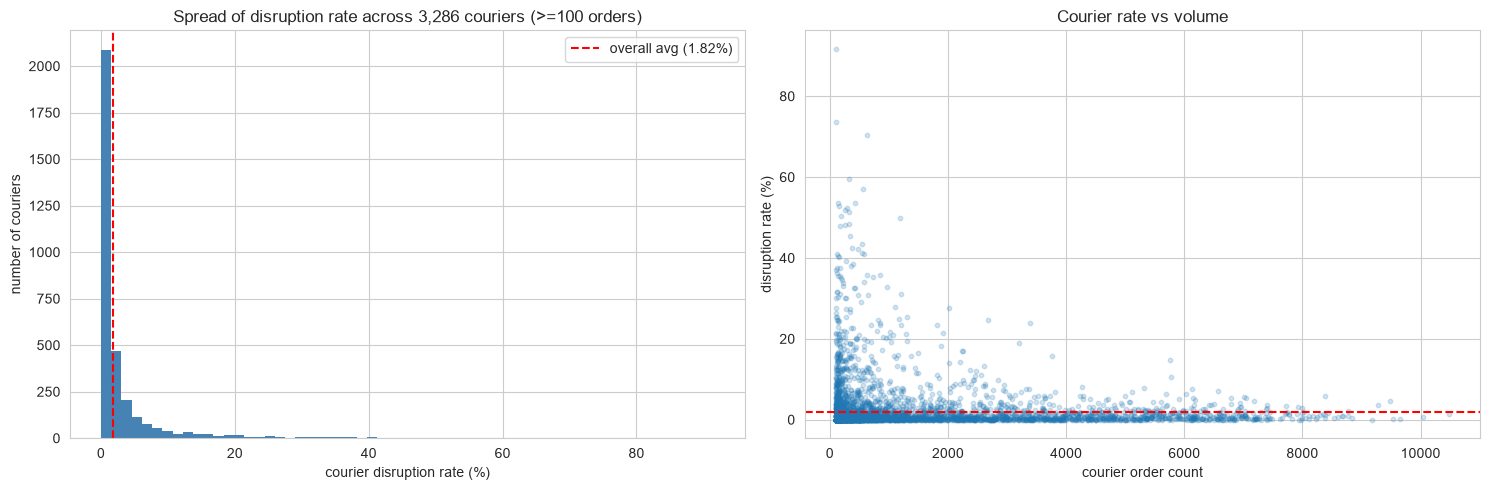

In [ ]:
courier_stats = df.groupby('courier_id').agg(
    disruption_rate=('is_disrupted', 'mean'),
    order_count=('is_disrupted', 'size')
).reset_index()
courier_stats['disruption_rate'] *= 100

MIN_ORDERS = 100
trusted = courier_stats[courier_stats['order_count'] >= MIN_ORDERS]

print(f"Total couriers: {len(courier_stats):,}")
print(f"Couriers with >= {MIN_ORDERS} orders: {len(trusted):,}")
print(f"\nDisruption rate distribution across trusted couriers:")
print(trusted['disruption_rate'].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(trusted['disruption_rate'], bins=60, color='steelblue', edgecolor='none')
ax1.axvline(1.82, color='red', linestyle='--', label='overall avg (1.82%)')
ax1.set_xlabel('courier disruption rate (%)')
ax1.set_ylabel('number of couriers')
ax1.set_title(f'Spread of disruption rate across {len(trusted):,} couriers (>={MIN_ORDERS} orders)')
ax1.legend()

ax2.scatter(trusted['order_count'], trusted['disruption_rate'], alpha=0.2, s=10)
ax2.axhline(1.82, color='red', linestyle='--')
ax2.set_xlabel('courier order count')
ax2.set_ylabel('disruption rate (%)')
ax2.set_title('Courier rate vs volume')

plt.tight_layout()
plt.show()

Total zones (aoi_id): 24,491
Zones with >= 100 orders: 9,928

Disruption rate distribution across trusted zones:
count    9928.000000
mean        1.763818
std         3.004443
min         0.000000
10%         0.000000
25%         0.000000
50%         0.884956
75%         2.250615
90%         4.263227
95%         6.299213
99%        12.516100
max        51.700680


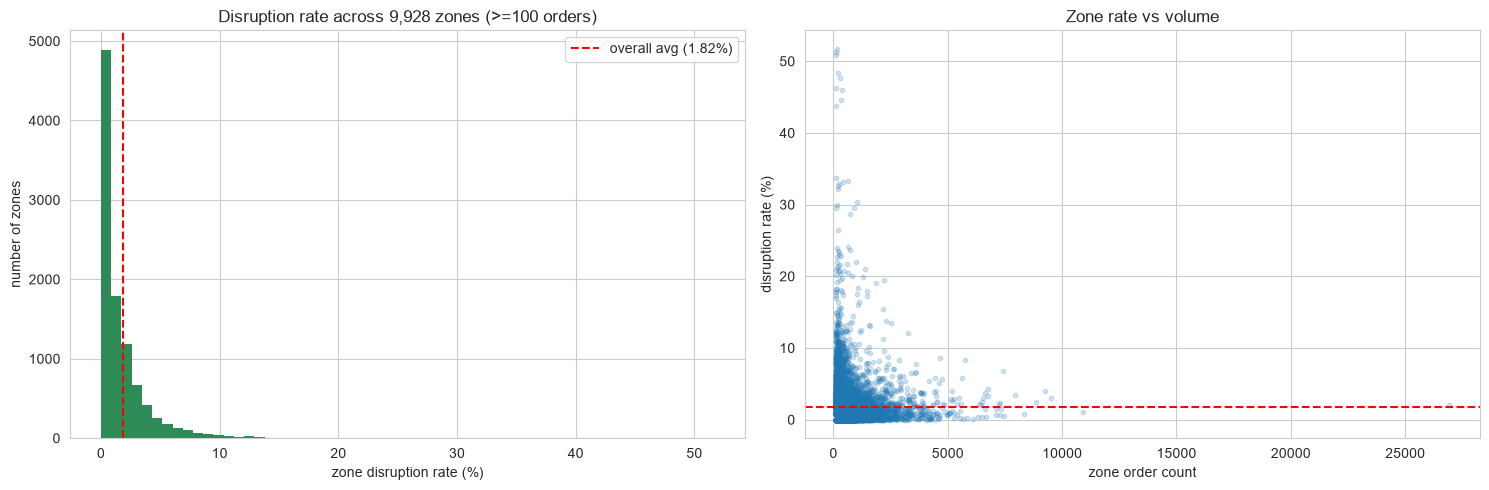

In [7]:
aoi_stats = df.groupby('aoi_id').agg(
    disruption_rate=('is_disrupted', 'mean'),
    order_count=('is_disrupted', 'size')
).reset_index()
aoi_stats['disruption_rate'] *= 100

MIN_ORDERS = 100
trusted_aoi = aoi_stats[aoi_stats['order_count'] >= MIN_ORDERS]

print(f"Total zones (aoi_id): {len(aoi_stats):,}")
print(f"Zones with >= {MIN_ORDERS} orders: {len(trusted_aoi):,}")
print(f"\nDisruption rate distribution across trusted zones:")
print(trusted_aoi['disruption_rate'].describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.hist(trusted_aoi['disruption_rate'], bins=60, color='seagreen', edgecolor='none')
ax1.axvline(1.82, color='red', linestyle='--', label='overall avg (1.82%)')
ax1.set_xlabel('zone disruption rate (%)')
ax1.set_ylabel('number of zones')
ax1.set_title(f'Disruption rate across {len(trusted_aoi):,} zones (>={MIN_ORDERS} orders)')
ax1.legend()

ax2.scatter(trusted_aoi['order_count'], trusted_aoi['disruption_rate'], alpha=0.2, s=10)
ax2.axhline(1.82, color='red', linestyle='--')
ax2.set_xlabel('zone order count')
ax2.set_ylabel('disruption rate (%)')
ax2.set_title('Zone rate vs volume')
plt.tight_layout()
plt.show()

 aoi_type  disruption_rate  order_count
       10         2.447480        19326
       11         2.283654         2496
        8         2.276558        36195
        2         2.157312       100310
        9         2.094738        31603
        5         2.039058         3482
        4         1.958855        64017
       14         1.888176      1689249
        1         1.781972      3658700
        0         1.771321       208432
        7         1.688168       135650
       12         1.605888        50813
       13         1.409754        18372
        3         1.391289        34141
        6         1.204422        12122


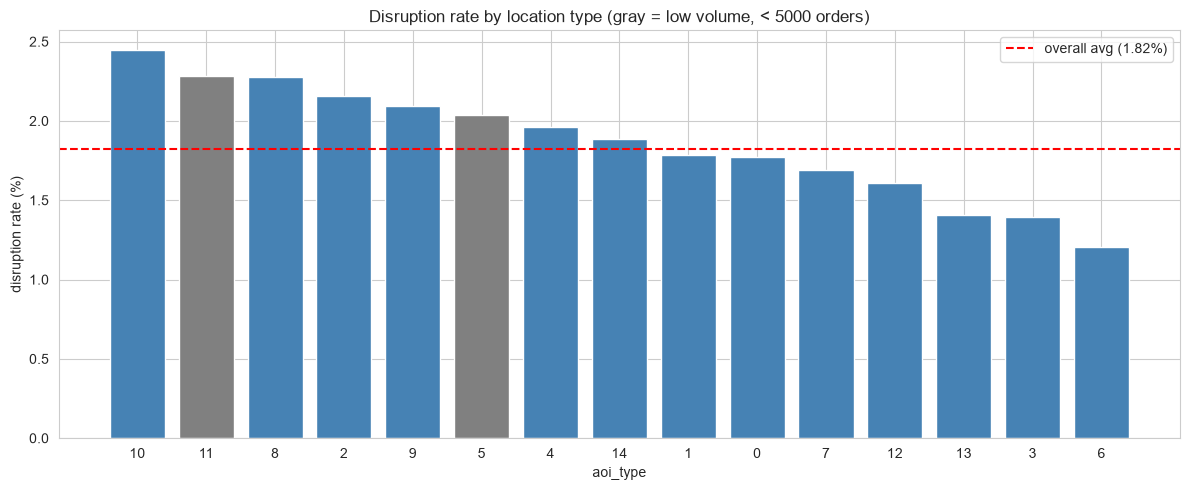

In [8]:
type_stats = df.groupby('aoi_type').agg(
    disruption_rate=('is_disrupted', 'mean'),
    order_count=('is_disrupted', 'size')
).reset_index()
type_stats['disruption_rate'] *= 100
type_stats = type_stats.sort_values('disruption_rate', ascending=False)

print(type_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['gray' if c < 5000 else 'steelblue' for c in type_stats['order_count']]
ax.bar(type_stats['aoi_type'].astype(str), type_stats['disruption_rate'], color=colors)
ax.axhline(1.82, color='red', linestyle='--', label='overall avg (1.82%)')
ax.set_xlabel('aoi_type')
ax.set_ylabel('disruption rate (%)')
ax.set_title('Disruption rate by location type (gray = low volume, < 5000 orders)')
ax.legend()
plt.tight_layout()
plt.show()

Window length distribution (minutes):
count    6.064908e+06
mean     1.243781e+02
std      6.921177e+01
min      4.000000e+00
10%      1.200000e+02
25%      1.200000e+02
50%      1.200000e+02
75%      1.200000e+02
90%      1.200000e+02
max      1.859000e+03

Disruption rate by window length:
window_bucket  disruption_rate  order_count
         0-1h         3.979439       136376
         1-2h         1.769701      5879695
         2-3h       100.000000            1
         3-4h       100.000000            1
          4h+         1.625883        48835


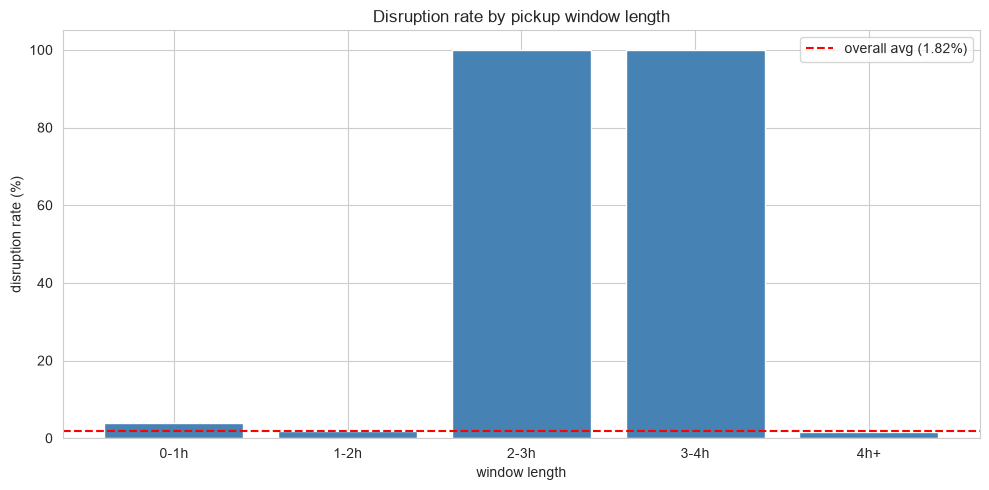

In [ ]:
df['window_minutes'] = (df['time_window_end'] - df['time_window_start']).dt.total_seconds() / 60

print("Window length distribution (minutes):")
print(df['window_minutes'].describe(percentiles=[.1,.25,.5,.75,.9]).to_string())

df['window_bucket'] = pd.cut(df['window_minutes'],
                              bins=[0, 60, 120, 180, 240, 10000],
                              labels=['0-1h','1-2h','2-3h','3-4h','4h+'])

bucket_stats = df.groupby('window_bucket').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
bucket_stats['disruption_rate'] *= 100
print("\nDisruption rate by window length:")
print(bucket_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(bucket_stats['window_bucket'].astype(str), bucket_stats['disruption_rate'], color='steelblue')
ax.axhline(1.82, color='red', linestyle='--', label='overall avg (1.82%)')
ax.set_xlabel('window length')
ax.set_ylabel('disruption rate (%)')
ax.set_title('Disruption rate by pickup window length')
ax.legend()
plt.tight_layout()
plt.show()

courier_orders_so_far distribution:
count    6.064908e+06
mean     1.717304e+01
std      1.361520e+01
min      0.000000e+00
50%      1.500000e+01
75%      2.600000e+01
90%      3.700000e+01
95%      4.300000e+01
99%      5.400000e+01
max      8.900000e+01

Disruption rate by daily load:
load_bucket  disruption_rate  order_count
        0-5         2.202312      1457741
       6-10         1.833682       902883
      11-20         1.663001      1520083
      21-40         1.551647      1782429
        40+         2.160429       401772


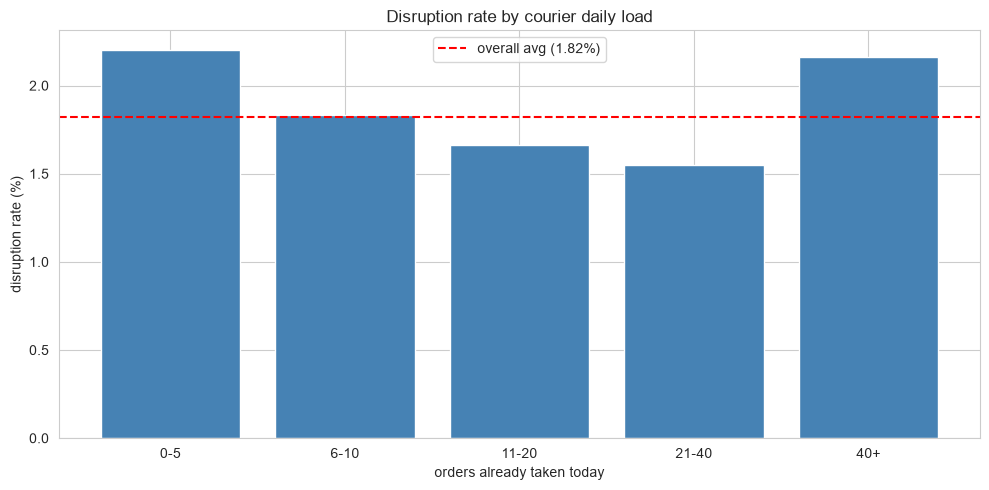

In [ ]:
df = df.sort_values(['courier_id', 'ds', 'accept_time']).reset_index(drop=True)

df['courier_orders_so_far'] = df.groupby(['courier_id', 'ds']).cumcount()

print("courier_orders_so_far distribution:")
print(df['courier_orders_so_far'].describe(percentiles=[.5,.75,.9,.95,.99]).to_string())

df['load_bucket'] = pd.cut(df['courier_orders_so_far'],
                            bins=[-1, 5, 10, 20, 40, 10000],
                            labels=['0-5','6-10','11-20','21-40','40+'])

load_stats = df.groupby('load_bucket').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
load_stats['disruption_rate'] *= 100
print("\nDisruption rate by daily load:")
print(load_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(load_stats['load_bucket'].astype(str), load_stats['disruption_rate'], color='steelblue')
ax.axhline(1.82, color='red', linestyle='--', label='overall avg (1.82%)')
ax.set_xlabel('orders already taken today')
ax.set_ylabel('disruption rate (%)')
ax.set_title('Disruption rate by courier daily load')
ax.legend()
plt.tight_layout()
plt.show()

Rows with distance: 3,318,203 (54.7%)
Rows missing (no GPS): 2,746,705

Distance distribution (km):
count    3.318203e+06
mean     1.334159e+00
std      7.526025e+00
min      0.000000e+00
50%      6.123402e-01
75%      1.385359e+00
90%      2.978685e+00
95%      4.407809e+00
99%      8.314211e+00
max      1.833677e+03

Disruption rate by distance:
dist_bucket  disruption_rate  order_count
     <0.5km         0.962180      1416783
    0.5-1km         1.068955       783288
      1-2km         1.163664       553854
      2-5km         1.690228       438225
     5-10km         2.420874       106160
      10km+         2.885437        19893


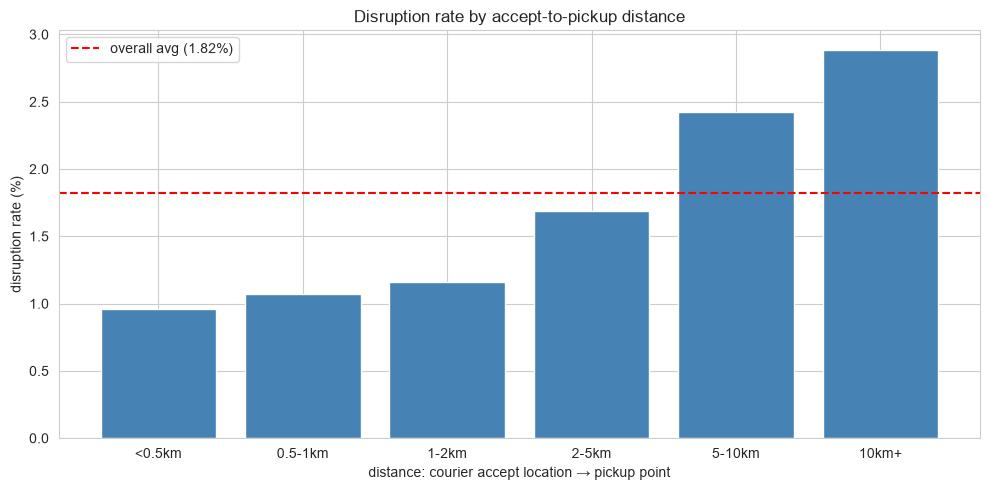

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # earth radius km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['accept_distance_km'] = haversine(
    df['accept_gps_lat'], df['accept_gps_lng'],
    df['lat'], df['lng']
)

valid = df['accept_distance_km'].notna()
print(f"Rows with distance: {valid.sum():,} ({valid.mean()*100:.1f}%)")
print(f"Rows missing (no GPS): {(~valid).sum():,}")
print(f"\nDistance distribution (km):")
print(df['accept_distance_km'].describe(percentiles=[.5,.75,.9,.95,.99]).to_string())

df['dist_bucket'] = pd.cut(df['accept_distance_km'],
                            bins=[-0.001, 0.5, 1, 2, 5, 10, 100000],
                            labels=['<0.5km','0.5-1km','1-2km','2-5km','5-10km','10km+'])

dist_stats = df[valid].groupby('dist_bucket').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
dist_stats['disruption_rate'] *= 100
print("\nDisruption rate by distance:")
print(dist_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(dist_stats['dist_bucket'].astype(str), dist_stats['disruption_rate'], color='steelblue')
ax.axhline(1.82, color='red', linestyle='--', label='overall avg (1.82%)')
ax.set_xlabel('distance: courier accept location → pickup point')
ax.set_ylabel('disruption rate (%)')
ax.set_title('Disruption rate by accept-to-pickup distance')
ax.legend()
plt.tight_layout()
plt.show()

 day_of_week  day_name  disruption_rate  order_count
           0    Monday         1.724366       891342
           1   Tuesday         1.826208       860143
           2 Wednesday         1.743243       836659
           3  Thursday         1.696358       822586
           4    Friday         1.623893       826101
           5  Saturday         2.096803       904806
           6    Sunday         1.979051       923271


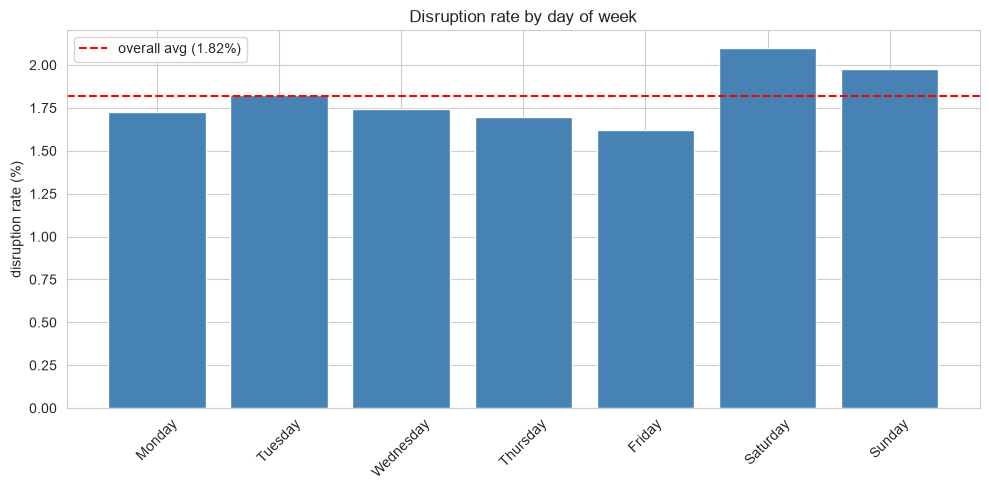

In [ ]:
def ds_to_date(ds):
    mm = ds // 100
    dd = ds % 100
    return pd.Timestamp(year=2022, month=mm, day=dd)

ds_map = {d: ds_to_date(d) for d in df['ds'].unique()}
df['real_date'] = df['ds'].map(ds_map)
df['day_of_week'] = df['real_date'].dt.dayofweek  # 0=Mon, 6=Sun
df['day_name'] = df['real_date'].dt.day_name()

dow_stats = df.groupby(['day_of_week','day_name']).agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
dow_stats['disruption_rate'] *= 100
print(dow_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(dow_stats['day_name'], dow_stats['disruption_rate'], color='steelblue')
ax.axhline(1.82, color='red', linestyle='--', label='overall avg (1.82%)')
ax.set_ylabel('disruption rate (%)')
ax.set_title('Disruption rate by day of week')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

accept_to_window_hrs distribution:
count    6.064908e+06
mean     3.117521e+00
std      6.864592e+00
min     -1.243333e+01
10%      0.000000e+00
25%      7.500000e-01
50%      1.283333e+00
75%      2.400000e+00
90%      6.466667e+00
95%      9.100000e+00
99%      3.196667e+01
max      2.010333e+02

Disruption rate by accept-to-window gap:
       gap_bucket  disruption_rate  order_count
<0 (already open)         1.803954       611102
             0-1h         1.777218      1563680
             1-2h         2.017918      2108460
             2-4h         1.763853       741275
             4-8h         1.306847       591959
              8h+         1.807186       448432


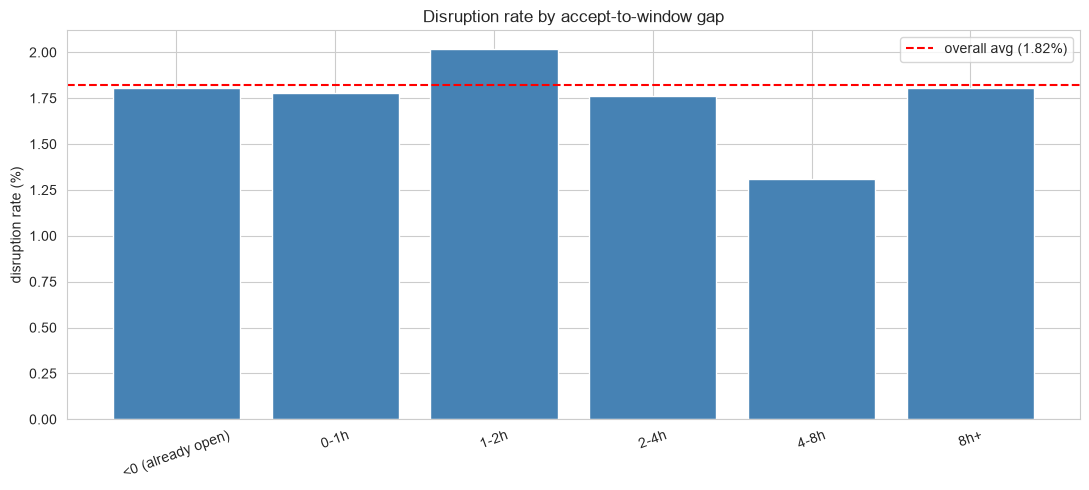

In [ ]:
df['accept_to_window_hrs'] = (df['time_window_start'] - df['accept_time']).dt.total_seconds() / 3600

print("accept_to_window_hrs distribution:")
print(df['accept_to_window_hrs'].describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).to_string())

df['gap_bucket'] = pd.cut(df['accept_to_window_hrs'],
                           bins=[-10000, 0, 1, 2, 4, 8, 10000],
                           labels=['<0 (already open)','0-1h','1-2h','2-4h','4-8h','8h+'])

gap_stats = df.groupby('gap_bucket').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
gap_stats['disruption_rate'] *= 100
print("\nDisruption rate by accept-to-window gap:")
print(gap_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(11,5))
ax.bar(gap_stats['gap_bucket'].astype(str), gap_stats['disruption_rate'], color='steelblue')
ax.axhline(1.82, color='red', linestyle='--', label='overall avg (1.82%)')
ax.set_ylabel('disruption rate (%)')
ax.set_title('Disruption rate by accept-to-window gap')
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
courier_rate = df.groupby('courier_id')['is_disrupted'].transform('mean')
aoi_rate = df.groupby('aoi_id')['is_disrupted'].transform('mean')

corr = np.corrcoef(courier_rate, aoi_rate)[0,1]
print(f"Correlation between courier rate and zone rate: {corr:.3f}")
print("\n(Near 0 = independent, both useful. Near 1 = redundant, one is enough.)")

Correlation between courier rate and zone rate: 0.555

(Near 0 = independent, both useful. Near 1 = redundant, one is enough.)


 month  disruption_rate  order_count
     5         1.419144       691473
     6         2.621169      1175010
     7         1.355756      1047312
     8         1.615700       962988
     9         1.859789      1069530
    10         1.789298      1118595


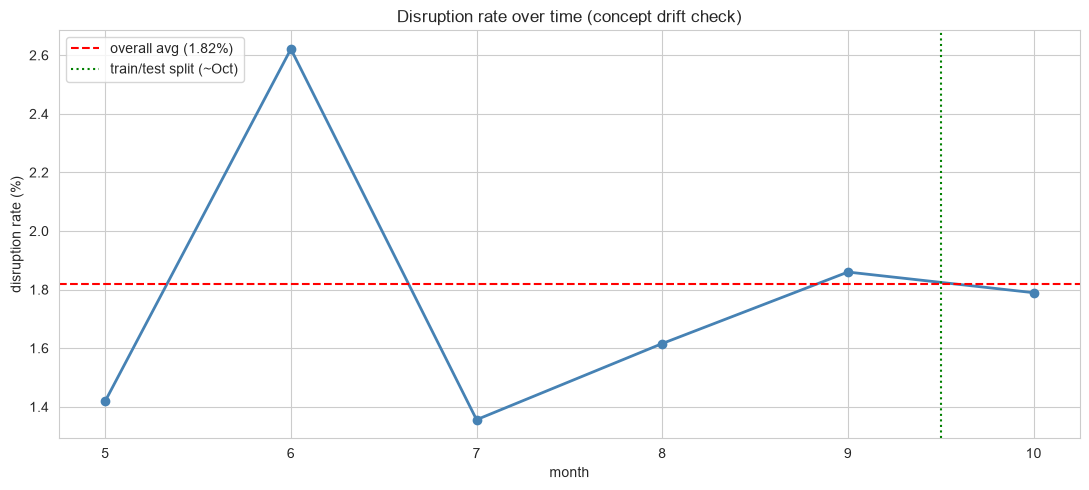

In [ ]:
df['month'] = df['real_date'].dt.month

month_stats = df.groupby('month').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
month_stats['disruption_rate'] *= 100
print(month_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(month_stats['month'], month_stats['disruption_rate'], marker='o', linewidth=2, color='steelblue')
ax.axhline(1.82, color='red', linestyle='--', label='overall avg (1.82%)')
ax.axvline(9.5, color='green', linestyle=':', label='train/test split (~Oct)')
ax.set_xlabel('month')
ax.set_ylabel('disruption rate (%)')
ax.set_title('Disruption rate over time (concept drift check)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
df = pd.read_parquet("../../data/processed/pickup_clean.parquet")
df['real_date'] = df['ds'].map({d: pd.Timestamp(year=2022, month=d//100, day=d%100) for d in df['ds'].unique()})
df = df.sort_values(['real_date','accept_time']).reset_index(drop=True)

df['hour_of_day'] = df['accept_time'].dt.hour
df['expected_duration'] = (df['time_window_end'] - df['time_window_start']).dt.total_seconds()/60

def haversine(lat1,lon1,lat2,lon2):
    R=6371; lat1,lon1,lat2,lon2=map(np.radians,[lat1,lon1,lat2,lon2])
    dlat,dlon=lat2-lat1,lon2-lon1
    a=np.sin(dlat/2)**2+np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R*2*np.arcsin(np.sqrt(a))
df['accept_distance_km'] = haversine(df['accept_gps_lat'],df['accept_gps_lng'],df['lat'],df['lng']).clip(upper=50)

print(f"Loaded: {df.shape}, disruption rate {df['is_disrupted'].mean()*100:.2f}%")

Loaded: (6064908, 22), disruption rate 1.82%


In [ ]:
df['velocity_target'] = df['expected_duration'] / (df['accept_distance_km'] + 0.1)

valid = df['accept_distance_km'].notna()
sub = df[valid].copy()

print("velocity_target distribution:")
print(sub['velocity_target'].describe(percentiles=[.1,.25,.5,.75,.9]).to_string())

sub['vt_bucket'] = pd.qcut(sub['velocity_target'], q=6, duplicates='drop')
vt_stats = sub.groupby('vt_bucket').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
vt_stats['disruption_rate'] *= 100
print("\nDisruption rate by velocity_target (low = rushed):")
print(vt_stats.to_string(index=False))

velocity_target distribution:
count    3.318203e+06
mean     2.276002e+02
std      2.188240e+02
min      1.197605e+00
10%      3.849291e+01
25%      7.946726e+01
50%      1.671734e+02
75%      3.060632e+02
90%      4.990957e+02
max      8.507167e+03

Disruption rate by velocity_target (low = rushed):
          vt_bucket  disruption_rate  order_count
    (1.197, 55.341]         1.938398       553034
  (55.341, 106.276]         1.186907       553034
 (106.276, 167.173]         1.069554       553034
 (167.173, 247.902]         0.987102       553033
 (247.902, 390.225]         0.957084       553034
(390.225, 8507.167]         0.913145       553034


In [ ]:
df['accept_dt'] = df['real_date'] + (df['accept_time'] - df['accept_time'].dt.normalize())

df = df.sort_values(['courier_id', 'accept_dt']).reset_index(drop=True)

def rolling_3h(group):
    s = pd.Series(1, index=group['accept_dt'])
    return s.rolling('3h', closed='left').count().fillna(0).values

df['courier_load_3h'] = (
    df.groupby('courier_id', group_keys=False)
      .apply(lambda g: pd.Series(
          pd.Series(1, index=g['accept_dt']).rolling('3h', closed='left').count().fillna(0).values,
          index=g.index))
)

print("courier_load_3h distribution:")
print(df['courier_load_3h'].describe(percentiles=[.5,.75,.9,.95,.99]).to_string())

courier_load_3h distribution:
count    6.064908e+06
mean     1.028221e+01
std      8.702338e+00
min      0.000000e+00
50%      8.000000e+00
75%      1.500000e+01
90%      2.300000e+01
95%      2.800000e+01
99%      3.600000e+01
max      7.700000e+01


Disruption rate by 3-hour rolling load:
load3h_bucket  disruption_rate  order_count
          0-5         1.792662      2194781
         6-10         1.488425      1491509
        11-15         1.740968       922188
        16-20         1.768988       625725
          20+         2.601044       830705


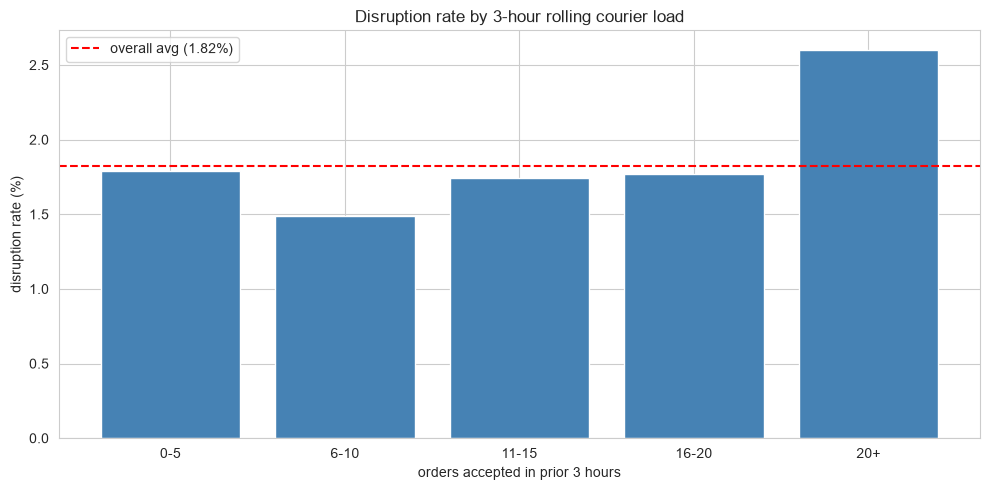

In [ ]:
df['load3h_bucket'] = pd.cut(df['courier_load_3h'],
                              bins=[-1, 5, 10, 15, 20, 1000],
                              labels=['0-5','6-10','11-15','16-20','20+'])

load3h_stats = df.groupby('load3h_bucket').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
load3h_stats['disruption_rate'] *= 100
print("Disruption rate by 3-hour rolling load:")
print(load3h_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(load3h_stats['load3h_bucket'].astype(str), load3h_stats['disruption_rate'], color='steelblue')
ax.axhline(1.82, color='red', linestyle='--', label='overall avg (1.82%)')
ax.set_xlabel('orders accepted in prior 3 hours')
ax.set_ylabel('disruption rate (%)')
ax.set_title('Disruption rate by 3-hour rolling courier load')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
df = df.sort_values(['courier_id', 'accept_dt']).reset_index(drop=True)

df['courier_running_rate'] = (
    df.groupby('courier_id')['is_disrupted']
      .transform(lambda x: x.shift(1).expanding().mean())
)

print(f"Rows with running rate: {df['courier_running_rate'].notna().sum():,}")
print(f"Rows NaN (courier's first order): {df['courier_running_rate'].isnull().sum():,}")
print("\ncourier_running_rate distribution (non-null):")
print(df['courier_running_rate'].describe(percentiles=[.5,.75,.9,.95,.99]).to_string())

Rows with running rate: 6,048,980
Rows NaN (courier's first order): 15,928

courier_running_rate distribution (non-null):
count    6.048980e+06
mean     2.123569e-02
std      5.474234e-02
min      0.000000e+00
50%      5.864548e-03
75%      1.886792e-02
90%      4.761905e-02
95%      8.745881e-02
99%      2.747036e-01
max      1.000000e+00


In [ ]:
valid = df['courier_running_rate'].notna()
sub = df[valid].copy()

sub['rr_bucket'] = pd.qcut(sub['courier_running_rate'], q=6, duplicates='drop')
rr_stats = sub.groupby('rr_bucket').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
rr_stats['disruption_rate'] *= 100
print("Disruption rate by courier running (recency) rate:")
print(rr_stats.to_string(index=False))

corr = sub['courier_running_rate'].corr(sub['is_disrupted'])
print(f"\nCorrelation with target: {corr:.4f}")

Disruption rate by courier running (recency) rate:
         rr_bucket  disruption_rate  order_count
 (-0.001, 0.00141]         0.228682      2016335
(0.00141, 0.00586]         0.400434      1008157
  (0.00586, 0.013]         0.930881      1008722
   (0.013, 0.0287]         1.850830      1007602
     (0.0287, 1.0]         7.210831      1008164

Correlation with target: 0.2998


In [ ]:
df['date_hour'] = df['ds'].astype(str) + '_' + df['hour_of_day'].astype(str)

congestion = df.groupby(['city', 'ds', 'hour_of_day']).agg(
    n_orders=('order_id', 'size'),
    n_couriers=('courier_id', 'nunique')
).reset_index()
congestion['orders_per_courier'] = congestion['n_orders'] / congestion['n_couriers']

print("orders_per_courier distribution (per city-day-hour):")
print(congestion['orders_per_courier'].describe(percentiles=[.5,.75,.9,.95,.99]).to_string())

df = df.merge(
    congestion[['city','ds','hour_of_day','orders_per_courier']],
    on=['city','ds','hour_of_day'], how='left'
)

sub = df.copy()
sub['cong_bucket'] = pd.qcut(sub['orders_per_courier'], q=6, duplicates='drop')
cong_stats = sub.groupby('cong_bucket').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
cong_stats['disruption_rate'] *= 100
print("\nDisruption rate by congestion (orders per courier):")
print(cong_stats.to_string(index=False))

orders_per_courier distribution (per city-day-hour):
count    11918.000000
mean         2.511701
std          1.818901
min          1.000000
50%          1.894737
75%          2.599834
90%          5.431676
95%          6.847852
99%          8.502643
max         14.478261

Disruption rate by congestion (orders per courier):
    cong_bucket  disruption_rate  order_count
   (0.999, 2.0]         1.042108      1021679
   (2.0, 2.566]         1.551342      1000682
 (2.566, 4.592]         1.706192      1010144
 (4.592, 5.961]         1.910868      1010797
 (5.961, 7.414]         2.090574      1013071
(7.414, 14.478]         2.615279      1008535


In [ ]:
zone_concurrency = df.groupby(['aoi_id', 'ds', 'hour_of_day']).agg(
    concurrent_orders=('order_id', 'size')
).reset_index()

print("concurrent_orders distribution (per zone-day-hour):")
print(zone_concurrency['concurrent_orders'].describe(percentiles=[.5,.75,.9,.95,.99]).to_string())

df = df.merge(
    zone_concurrency[['aoi_id','ds','hour_of_day','concurrent_orders']],
    on=['aoi_id','ds','hour_of_day'], how='left'
)

sub = df.copy()
sub['conc_bucket'] = pd.cut(sub['concurrent_orders'],
                             bins=[0,1,2,3,5,10,10000],
                             labels=['1','2','3','4-5','6-10','10+'])
conc_stats = sub.groupby('conc_bucket').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
conc_stats['disruption_rate'] *= 100
print("\nDisruption rate by zone concurrency:")
print(conc_stats.to_string(index=False))

concurrent_orders distribution (per zone-day-hour):
count    3.915791e+06
mean     1.548833e+00
std      1.396887e+00
min      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
90%      3.000000e+00
95%      4.000000e+00
99%      7.000000e+00
max      1.120000e+02

Disruption rate by zone concurrency:
conc_bucket  disruption_rate  order_count
          1         1.544682      2847123
          2         1.739425      1250068
          3         1.920455       648336
        4-5         2.083459       631690
       6-10         2.486304       493946
        10+         3.437508       193745


In [ ]:
df = df.sort_values(['courier_id', 'accept_dt']).reset_index(drop=True)

df['mins_since_last_accept'] = (
    df.groupby('courier_id')['accept_dt']
      .diff()  # current - previous
      .dt.total_seconds() / 60
)

print(f"Rows with value: {df['mins_since_last_accept'].notna().sum():,}")
print(f"NaN (first accept per courier): {df['mins_since_last_accept'].isnull().sum():,}")
print("\nmins_since_last_accept distribution:")
print(df['mins_since_last_accept'].describe(percentiles=[.25,.5,.75,.9,.95,.99]).to_string())

Rows with value: 6,048,980
NaN (first accept per courier): 15,928

mins_since_last_accept distribution:
count    6.048980e+06
mean     2.639496e+02
std      2.653061e+03
min      0.000000e+00
25%      2.000000e+00
50%      8.000000e+00
75%      2.700000e+01
90%      8.800000e+01
95%      8.890000e+02
99%      4.602000e+03
max      2.592950e+05


In [ ]:
df['mins_since_last_accept'] = df['mins_since_last_accept'].clip(upper=240)

print("After capping at 240 min:")
print(df['mins_since_last_accept'].describe(percentiles=[.25,.5,.75,.9,.95]).to_string())

valid = df['mins_since_last_accept'].notna()
sub = df[valid].copy()
sub['gap_bucket'] = pd.cut(sub['mins_since_last_accept'],
                            bins=[-1, 2, 5, 15, 60, 240],
                            labels=['0-2','3-5','6-15','16-60','60+'])
gap_stats = sub.groupby('gap_bucket').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
gap_stats['disruption_rate'] *= 100
print("\nDisruption rate by time since last accept:")
print(gap_stats.to_string(index=False))

After capping at 240 min:
count    6.048980e+06
mean     3.242554e+01
std      6.186944e+01
min      0.000000e+00
25%      2.000000e+00
50%      8.000000e+00
75%      2.700000e+01
90%      8.800000e+01
95%      2.400000e+02
max      2.400000e+02

Disruption rate by time since last accept:
gap_bucket  disruption_rate  order_count
       0-2         2.277747      1638944
       3-5         1.970974       975203
      6-15         1.611891      1305547
     16-60         1.292044      1326967
       60+         1.825085       802319


In [ ]:
df = df.sort_values(['courier_id', 'accept_dt']).reset_index(drop=True)

df['travel_mins'] = (df['pickup_time'] - df['accept_time']).dt.total_seconds() / 60

df['realized_speed'] = df['accept_distance_km'] / (df['travel_mins'].clip(lower=1))

df['courier_hist_speed'] = (
    df.groupby('courier_id')['realized_speed']
      .transform(lambda x: x.shift(1).expanding().mean())
)

valid = df['courier_hist_speed'].notna() & df['accept_distance_km'].notna()
sub = df[valid].copy()

print(f"Rows with hist speed + distance: {len(sub):,}")
print("\ncourier_hist_speed distribution:")
print(sub['courier_hist_speed'].describe(percentiles=[.5,.9,.99]).to_string())

sub['spd_bucket'] = pd.qcut(sub['courier_hist_speed'], q=5, duplicates='drop')
spd_stats = sub.groupby('spd_bucket').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
spd_stats['disruption_rate'] *= 100
print("\nDisruption rate by courier historical speed:")
print(spd_stats.to_string(index=False))

corr = sub['courier_hist_speed'].corr(sub['is_disrupted'])
print(f"\nCorrelation with target: {corr:.4f}")

Rows with hist speed + distance: 3,313,057

courier_hist_speed distribution:
count    3.313057e+06
mean     1.938275e-02
std      4.441175e-02
min      1.359316e-05
50%      1.545111e-02
90%      3.186963e-02
99%      7.060623e-02
max      1.868545e+01

Disruption rate by courier historical speed:
                      spd_bucket  disruption_rate  order_count
(-0.0009864000000000001, 0.0101]         1.455603       662612
                (0.0101, 0.0136]         1.175652       662611
                (0.0136, 0.0177]         1.055823       662611
                (0.0177, 0.0247]         1.109550       662611
                (0.0247, 18.685]         1.060047       662612

Correlation with target: -0.0021


In [ ]:
df = df.sort_values(['courier_id', 'aoi_id', 'accept_dt']).reset_index(drop=True)

df['courier_zone_familiarity'] = df.groupby(['courier_id', 'aoi_id']).cumcount()

print("courier_zone_familiarity distribution:")
print(df['courier_zone_familiarity'].describe(percentiles=[.5,.75,.9,.95,.99]).to_string())

df['fam_bucket'] = pd.cut(df['courier_zone_familiarity'],
                           bins=[-1, 0, 2, 5, 20, 100000],
                           labels=['0 (first time)','1-2','3-5','6-20','20+'])
fam_stats = df.groupby('fam_bucket').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
fam_stats['disruption_rate'] *= 100
print("\nDisruption rate by courier-zone familiarity:")
print(fam_stats.to_string(index=False))

corr = df['courier_zone_familiarity'].corr(df['is_disrupted'])
print(f"\nCorrelation with target: {corr:.4f}")

courier_zone_familiarity distribution:
count    6.064908e+06
mean     3.847544e+02
std      6.593614e+02
min      0.000000e+00
50%      1.310000e+02
75%      4.330000e+02
90%      1.056000e+03
95%      1.658000e+03
99%      3.359000e+03
max      6.845000e+03

Disruption rate by courier-zone familiarity:
    fam_bucket  disruption_rate  order_count
0 (first time)         4.752408       179004
           1-2         3.690720       210799
           3-5         3.133816       216924
          6-20         2.505853       646646
           20+         1.475350      4811535

Correlation with target: -0.0246


In [ ]:
df = df.sort_values(['aoi_id', 'accept_dt']).reset_index(drop=True)

df['zone_running_rate'] = (
    df.groupby('aoi_id')['is_disrupted']
      .transform(lambda x: x.shift(1).expanding().mean())
)

valid = df['zone_running_rate'].notna()
sub = df[valid].copy()

print(f"Rows with value: {valid.sum():,}")
print(f"NaN (zone's first order): {(~valid).sum():,}")

sub['zrr_bucket'] = pd.qcut(sub['zone_running_rate'], q=6, duplicates='drop')
zrr_stats = sub.groupby('zrr_bucket').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
zrr_stats['disruption_rate'] *= 100
print("\nDisruption rate by zone running rate:")
print(zrr_stats.to_string(index=False))

corr = sub['zone_running_rate'].corr(sub['is_disrupted'])
print(f"\nCorrelation with target: {corr:.4f}")

Rows with value: 6,040,417
NaN (zone's first order): 24,491

Disruption rate by zone running rate:
        zrr_bucket  disruption_rate  order_count
 (-0.001, 0.00205]         0.540906      2013474
(0.00205, 0.00869]         0.672272      1006735
 (0.00869, 0.0177]         1.322783      1006817
  (0.0177, 0.0341]         2.237787      1007692
     (0.0341, 1.0]         5.572443      1005699

Correlation with target: 0.1856


In [ ]:
df = df.sort_values(['courier_id', 'ds', 'accept_dt']).reset_index(drop=True)
df['courier_orders_so_far'] = df.groupby(['courier_id', 'ds']).cumcount()

df['is_first_order_of_day'] = (df['courier_orders_so_far'] == 0).astype(int)

print("is_first_order_of_day distribution:")
print(df['is_first_order_of_day'].value_counts())
print(f"\nShare that are first-of-day: {df['is_first_order_of_day'].mean()*100:.1f}%")

fod_stats = df.groupby('is_first_order_of_day').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
fod_stats['disruption_rate'] *= 100
print("\nDisruption rate: first order vs rest:")
print(fod_stats.to_string(index=False))

is_first_order_of_day distribution:
is_first_order_of_day
0    5683470
1     381438
Name: count, dtype: int64

Share that are first-of-day: 6.3%

Disruption rate: first order vs rest:
 is_first_order_of_day  disruption_rate  order_count
                     0         1.778139      5683470
                     1         2.416120       381438


In [ ]:
df['is_rush'] = df['hour_of_day'].between(7, 9).astype(int)
df['is_far'] = (df['accept_distance_km'] > 2).astype(int)

df['rush_far_combo'] = df['is_rush'].astype(str) + '_' + df['is_far'].astype(str)

valid = df['accept_distance_km'].notna()
sub = df[valid].copy()

combo_stats = sub.groupby('rush_far_combo').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
combo_stats['disruption_rate'] *= 100
combo_stats.columns = ['rush_far (rush_far)', 'disruption_rate', 'order_count']
print("Disruption rate by rush × far combination:")
print("(0_0=calm+near, 1_0=rush+near, 0_1=calm+far, 1_1=rush+far)")
print(combo_stats.to_string(index=False))

Disruption rate by rush × far combination:
(0_0=calm+near, 1_0=rush+near, 0_1=calm+far, 1_1=rush+far)
rush_far (rush_far)  disruption_rate  order_count
                0_0         0.860036      1247041
                0_1         1.162627        92549
                1_0         1.176268      1506884
                1_1         2.008568       471729


In [ ]:
courier_first_date = df.groupby('courier_id')['real_date'].transform('min')

df['courier_tenure_days'] = (df['real_date'] - courier_first_date).dt.days

print("courier_tenure_days distribution:")
print(df['courier_tenure_days'].describe(percentiles=[.25,.5,.75,.9]).to_string())

df['tenure_bucket'] = pd.cut(df['courier_tenure_days'],
                              bins=[-1, 7, 30, 60, 120, 10000],
                              labels=['0-7d (new)','8-30d','31-60d','61-120d','120d+ (veteran)'])
ten_stats = df.groupby('tenure_bucket').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
ten_stats['disruption_rate'] *= 100
print("\nDisruption rate by courier tenure:")
print(ten_stats.to_string(index=False))

corr = df['courier_tenure_days'].corr(df['is_disrupted'])
print(f"\nCorrelation with target: {corr:.4f}")

courier_tenure_days distribution:
count    6.064908e+06
mean     6.313234e+01
std      4.784421e+01
min      0.000000e+00
25%      2.200000e+01
50%      5.300000e+01
75%      9.700000e+01
90%      1.360000e+02
max      1.830000e+02

Disruption rate by courier tenure:
  tenure_bucket  disruption_rate  order_count
     0-7d (new)         3.694362       590332
          8-30d         2.111662      1374557
         31-60d         1.947470      1391292
        61-120d         1.204955      1769277
120d+ (veteran)         1.173772       939450

Correlation with target: -0.0445


In [ ]:
print("expected_duration distribution:")
print(df['expected_duration'].describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).to_string())

val_counts = df['expected_duration'].value_counts().head(8)
print("\nMost common window lengths (minutes):")
print(val_counts)
print(f"\nShare exactly 120 min: {(df['expected_duration']==120).mean()*100:.1f}%")

df['dur_bucket'] = pd.cut(df['expected_duration'],
                           bins=[0, 60, 119, 121, 240, 10000],
                           labels=['<60','60-119','120 (standard)','121-240','240+'])
dur_stats = df.groupby('dur_bucket').agg(
    disruption_rate=('is_disrupted','mean'),
    order_count=('is_disrupted','size')
).reset_index()
dur_stats['disruption_rate'] *= 100
print("\nDisruption rate by window length:")
print(dur_stats.to_string(index=False))

expected_duration distribution:
count    6.064908e+06
mean     1.243781e+02
std      6.921177e+01
min      4.000000e+00
10%      1.200000e+02
25%      1.200000e+02
50%      1.200000e+02
75%      1.200000e+02
90%      1.200000e+02
95%      1.200000e+02
99%      1.200000e+02
max      1.859000e+03

Most common window lengths (minutes):
expected_duration
120.0    5879693
60.0      136370
899.0      20367
489.0         78
459.0         78
597.0         77
562.0         76
580.0         73
Name: count, dtype: int64

Share exactly 120 min: 96.9%

Disruption rate by window length:
    dur_bucket  disruption_rate  order_count
           <60         3.979439       136376
        60-119        50.000000            2
120 (standard)         1.769684      5879693
       121-240       100.000000            2
          240+         1.625883        48835
